In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

#### Leer datos vector

In [17]:
# Read the GeoJSON file
fallas = gpd.read_file('Datos/Mapa_GeolB3gico_de_Colombia_2015._Escala_1%3A1.000.000.geojson')
depart = gpd.read_file('Datos/Servicio-23\Departamentos_Abril_2026_shp\Depto.shp')

In [18]:
fallas.head()

,OBJECTID,Tipo,NombreFalla,Comentarios,GlobalID,Shape__Length,geometry
0,13687,Falla,NaN,None,525f310a-5944-4c95-b958-c91e6d6f4d27,0.139363,"LINESTRING (-72.89873 6.34496, -72.89316 6.344..."
1,13690,Falla,Falla de Chaguaca,None,ac1c2068-f814-4261-96f1-07511a569a35,0.013992,"LINESTRING (-72.77309 6.17363, -72.77141 6.165..."
2,13691,Falla,Falla de Chaguaca,None,07eeeda1-ec6d-4b89-839e-6c6e446000b4,0.157835,"LINESTRING (-72.81564 5.98508, -72.81506 5.986..."
3,13692,Falla inversa o de cabalgamiento,Falla de Soápaga,None,14dbf299-4126-4d94-b6ca-902c97ad5a27,0.084160,"LINESTRING (-72.71945 6.11084, -72.71961 6.104..."
4,13693,Falla cubierta,Falla de Soápaga,None,3320158f-fc99-47f7-b9c2-4eb4986905b4,0.031333,"LINESTRING (-72.66563 6.1713, -72.6676 6.16892..."


In [20]:
depart.head()

,DeCodigo,DeNombre,DeArea,DeNorma,SHAPE_Leng,SHAPE_Area,geometry
0,00,Area en Litigio Cauca - Huila,342.099087,Límite por Acuerdo Gobernadores Informe 1982,1.093000e+05,3.420991e+08,"POLYGON ((4628086.408 1824018.057, 4628427.45 ..."
1,17,Caldas,7422.208349,Ley No.17 de 1905,7.359800e+05,7.422208e+09,"POLYGON ((4813988.018 2196861.468, 4814065.96 ..."
2,18,Caquetá,92709.074851,Constitución Política de Colombia 1991,2.352172e+06,9.270907e+10,"POLYGON ((4800106.596 1882811.417, 4800522.264..."
3,25,Cundinamarca,23963.653733,Constitución Política de Colombia 1886,1.167148e+06,2.396365e+10,"POLYGON ((4853080.426 2201709.922, 4853123.184..."
4,41,Huila,18137.066737,Ley No. 46 de 1905,1.145831e+06,1.813707e+10,"POLYGON ((4831449.806 1982029.406, 4831563.239..."


#### Proyecciones

In [25]:
depart.crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [21]:
fallas.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [22]:
fallas_reprojected = fallas.to_crs('EPSG:9377')

In [23]:
fallas_reprojected.crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [24]:
# Create new column with length in meters
fallas_reprojected['length_meters'] = fallas_reprojected.geometry.length

fallas_reprojected['length_km']=fallas_reprojected['length_meters']/1000

# View the results
print(fallas_reprojected[['NombreFalla', 'length_km']].head(10))

# Check statistics
print("\nLength statistics (meters):")
print(f"Mean: {fallas_reprojected['length_km'].mean():.2f} km")
print(f"Median: {fallas_reprojected['length_km'].median():.2f} km")
print(f"Min: {fallas_reprojected['length_km'].min():.2f} km")
print(f"Max: {fallas_reprojected['length_km'].max():.2f} km")

         NombreFalla  length_km
0                NaN  15.404917
1  Falla de Chaguaca   1.546194
2  Falla de Chaguaca  17.444411
3   Falla de Soápaga   9.303214
4   Falla de Soápaga   3.463406
5   Falla de Soápaga   2.807693
6                NaN   0.974721
7                NaN   1.749728
8                NaN   0.867533
9                NaN   2.247716

Length statistics (meters):
Mean: 11.78 km
Median: 6.29 km
Min: 0.00 km
Max: 414.65 km


In [26]:
fallas_reprojected.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4866 entries, 0 to 4865
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   OBJECTID       4866 non-null   int32   
 1   Tipo           4866 non-null   str     
 2   NombreFalla    2050 non-null   str     
 3   Comentarios    0 non-null      object  
 4   GlobalID       4866 non-null   str     
 5   Shape__Length  4866 non-null   float64 
 6   geometry       4866 non-null   geometry
 7   length_meters  4866 non-null   float64 
 8   length_km      4866 non-null   float64 
dtypes: float64(3), geometry(1), int32(1), object(1), str(3)
memory usage: 323.3+ KB


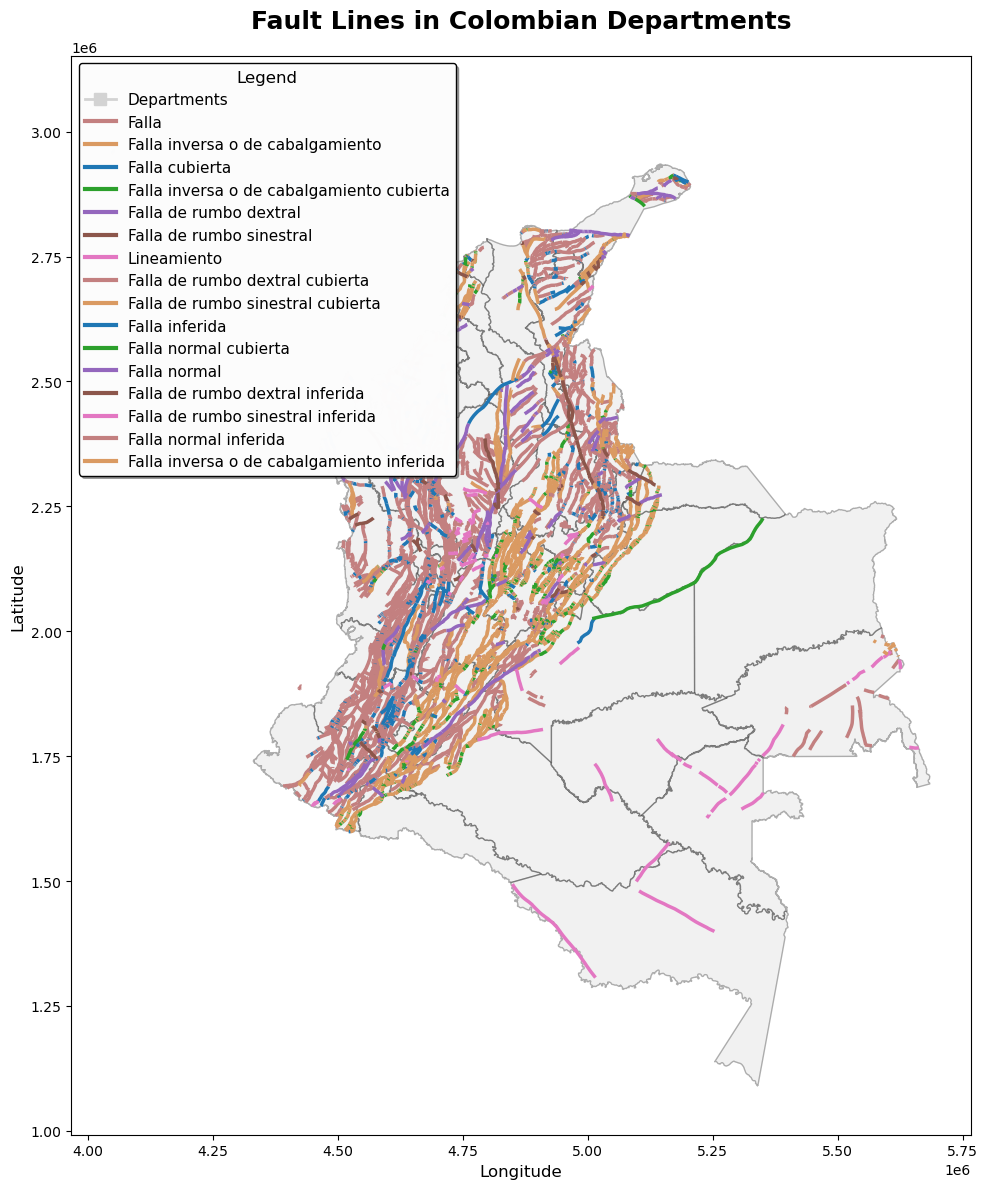

In [27]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Plot departments
depart.plot(ax=ax, alpha=0.3, edgecolor='black', color='lightgray')

# Plot faults by type
fault_types = fallas_reprojected['Tipo'].unique()
colors = ["#c38080", "#da9a62", '#1f77b4', '#2ca02c', '#9467bd', '#8c564b', '#e377c2']

for idx, fault_type in enumerate(fault_types):
    falla_subset = fallas_reprojected[fallas_reprojected['Tipo'] == fault_type]
    falla_subset.plot(ax=ax, color=colors[idx % len(colors)], linewidth=2.5)

plt.title('Fault Lines in Colombian Departments', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Create custom legend
legend_elements = [
    Line2D([0], [0], color='lightgray', linewidth=2, label='Departments', marker='s', markersize=8),
] + [
    Line2D([0], [0], color=colors[idx % len(colors)], linewidth=3, label=fault_type)
    for idx, fault_type in enumerate(fault_types)
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=11, 
          framealpha=0.98, edgecolor='black', fancybox=True, shadow=True, 
          title='Legend', title_fontsize=12)

plt.tight_layout()
plt.show()

Top 5 longest faults:
1. Falla del Meta - Length: 414.653859
2. nan - Length: 251.812726
3. nan - Length: 171.464326
4. nan - Length: 169.409209
5. Falla de Algeciras - Length: 162.559102


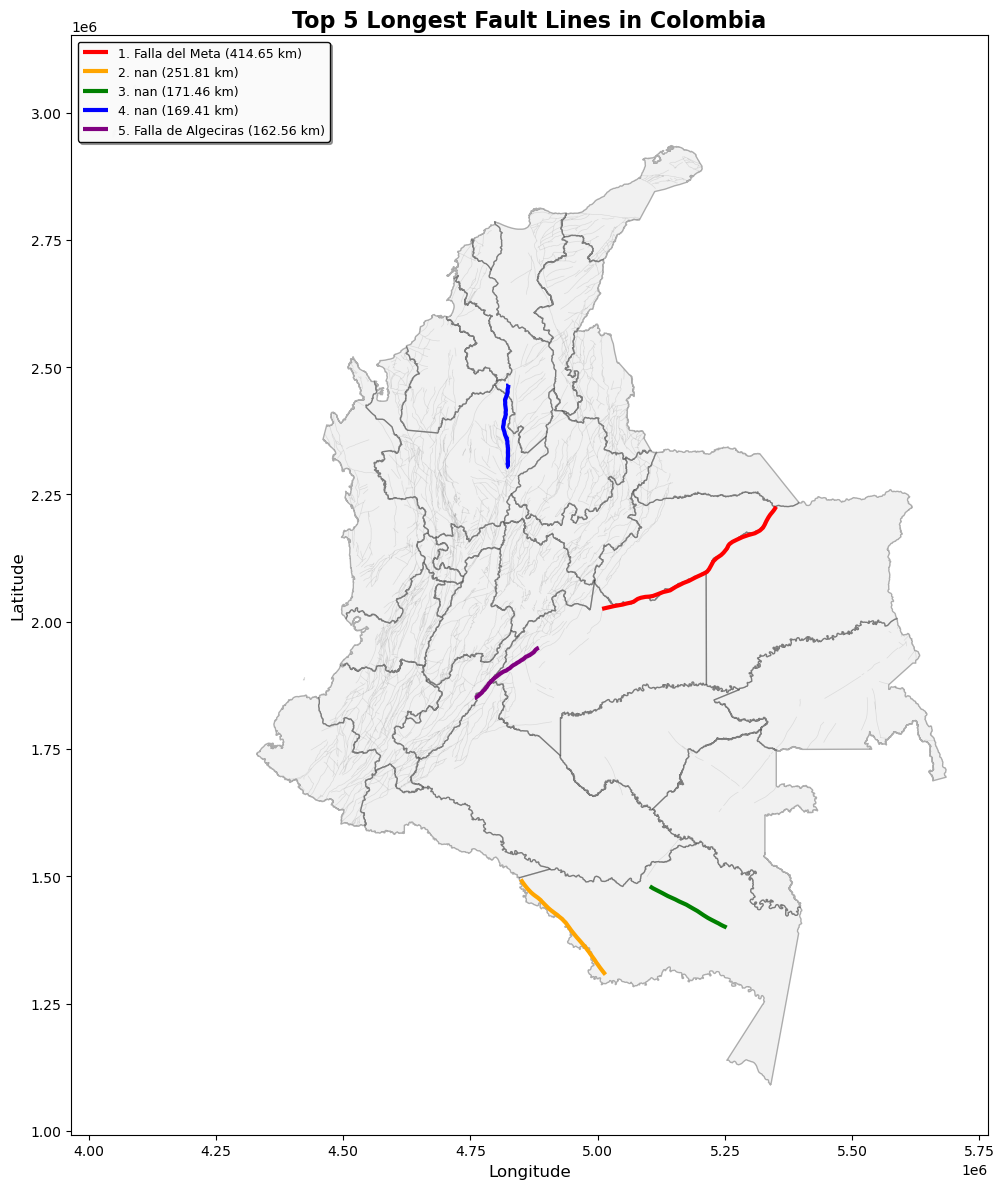

In [28]:
# Get top 5 longest faults
top_5 = fallas_reprojected.nlargest(5, 'length_km')

print("Top 5 longest faults:")
for idx, (i, row) in enumerate(top_5.iterrows(), 1):
    print(f"{idx}. {row['NombreFalla']} - Length: {row['length_km']:.6f}")

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Plot departments
depart.plot(ax=ax, alpha=0.3, edgecolor='black', color='lightgray')

# Plot all faults (light)
fallas_reprojected.plot(ax=ax, alpha=0.2, color='gray', linewidth=0.5)

# Plot top 5 with different colors
colors = ['red', 'orange', 'green', 'blue', 'purple']
for idx, (i, row) in enumerate(top_5.iterrows()):
    gpd.GeoSeries(row.geometry).plot(ax=ax, color=colors[idx], linewidth=3, 
                      label=f"{idx+1}. {row['NombreFalla']} ({row['length_km']:.2f} km)")

plt.title('Top 5 Longest Fault Lines in Colombia', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
ax.legend(loc='upper left', fontsize=9, framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)

plt.tight_layout()
plt.show()